In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
import csv
%matplotlib inline

In [15]:
import zipfile

In [23]:
path = os.path.abspath(os.path.join(os.getcwd(), '..'))
path = os.path.join(path,'companies_no_subindustry.zip')
print(path)

/Users/hualesan/anaconda_projects/companies_no_subindustry.zip


In [24]:
with zipfile.ZipFile(path) as z:
    print(z.namelist())

['companies_no_subindustry.csv', '__MACOSX/._companies_no_subindustry.csv']


In [42]:
with zipfile.ZipFile(path) as z:
    with z.open('companies_no_subindustry.csv') as f:
        df = pd.read_csv(f)

In [69]:
missing_included = df['included'].isna().sum()
print("Missing inclusion dates:", missing_included)

Missing inclusion dates: 45


In [70]:
df2 = df.dropna(subset=['included']).copy()

df2['included'] = pd.to_datetime(df2['included'], dayfirst=True, errors='coerce')

oldest = df2.loc[df2['included'].idxmin()]
youngest = df2.loc[df2['included'].idxmax()]

print("Oldest constituent:")
print(oldest[['Symbol', 'Security', 'included']])

print("\nYoungest constituent:")
print(youngest[['Symbol', 'Security', 'included']])

Oldest constituent:
Symbol                       MO
Security                 Altria
included    1957-03-04 00:00:00
Name: 25, dtype: object

Youngest constituent:
Symbol                     ACGL
Security     Arch Capital Group
included    2022-11-01 00:00:00
Name: 48, dtype: object


In [71]:
df2['Founded_year'] = pd.to_numeric(df2['Founded'].astype(str).str[:4], errors='coerce')

current_year = pd.Timestamp.today().year
df2['Age'] = current_year - df2['Founded_year']

median_age = df2['Age'].median()
print("\nMedian age:", median_age)


Median age: 54.5


GICS_Sector
Information Technology    68
Industrials               66
Health Care               60
Financials                55
Consumer Discretionary    52
Consumer Staples          33
Real Estate               30
Materials                 26
Communication Services    23
Utilities                 23
Energy                    22
Name: count, dtype: int64


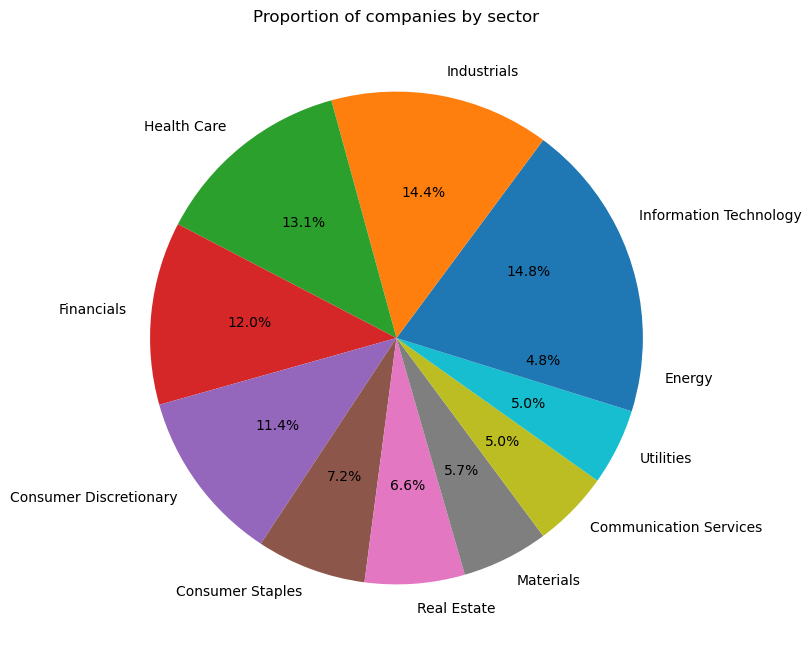

In [72]:
sector_counts = df2['GICS_Sector'].value_counts()
print(sector_counts)

sector_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title('Proportion of companies by sector')
plt.ylabel('')
plt.show()

In [74]:
df2['state'] = df2['hq'].astype(str).str.split(',').str[-1].str.strip()

state_counts = df2['state'].value_counts()
print(state_counts)

state
California                    65
New York                      44
Texas                         41
Illinois                      31
Pennsylvania                  19
Massachusetts                 18
Ohio                          17
North Carolina                16
Georgia                       16
Florida                       15
New Jersey                    15
Virginia                      15
Connecticut                   13
Minnesota                     13
Washington                    12
Michigan                      10
Tennessee                      8
Colorado                       7
Ireland                        7
Indiana                        6
Wisconsin                      6
Missouri                       6
Arizona                        5
Maryland                       5
Nevada                         4
Oklahoma                       4
Rhode Island                   4
United Kingdom                 4
Switzerland                    3
Arkansas                       3
Loui